In [266]:
words = open('names.txt', 'r').read().splitlines()

In [267]:
words[:10]


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [268]:
len(words)

32033

In [269]:
min(len(w) for w in words)

2

In [270]:
max(len(w) for w in words)

15

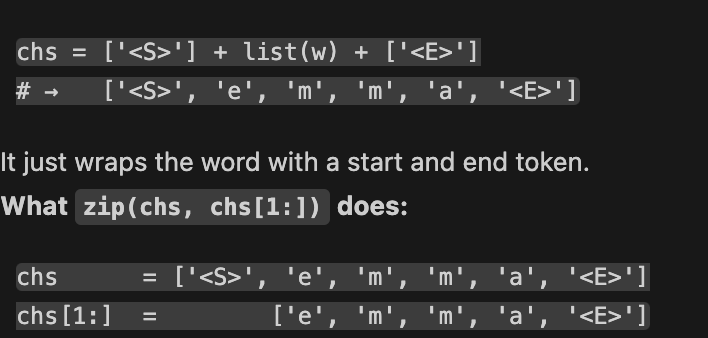

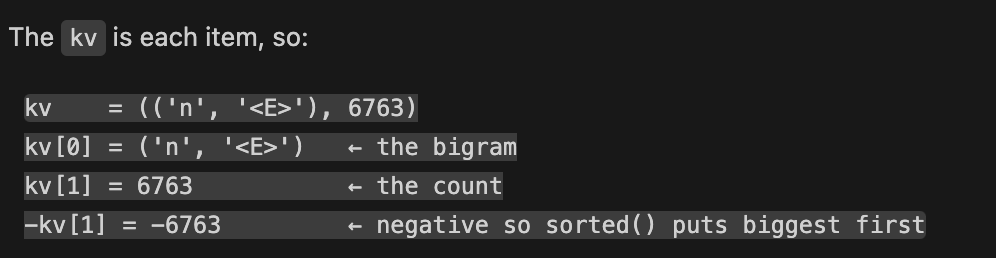

In [271]:
import torch

In [272]:
N = torch.zeros((28,28), dtype=torch.int32)

In [273]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1  for i,s in enumerate(chars)} # the map of words 

stoi['.'] = 0 
# stoi['<S>'] = 26 
# stoi['<E>'] = 27

print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [274]:

for w in words:    
    
    chs = ['.'] + list(w) + ['.']     
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 
        
        

In [275]:
import matplotlib.pyplot as plt 
%matplotlib inline

itos = {i:s for s,i in stoi.items()}

print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

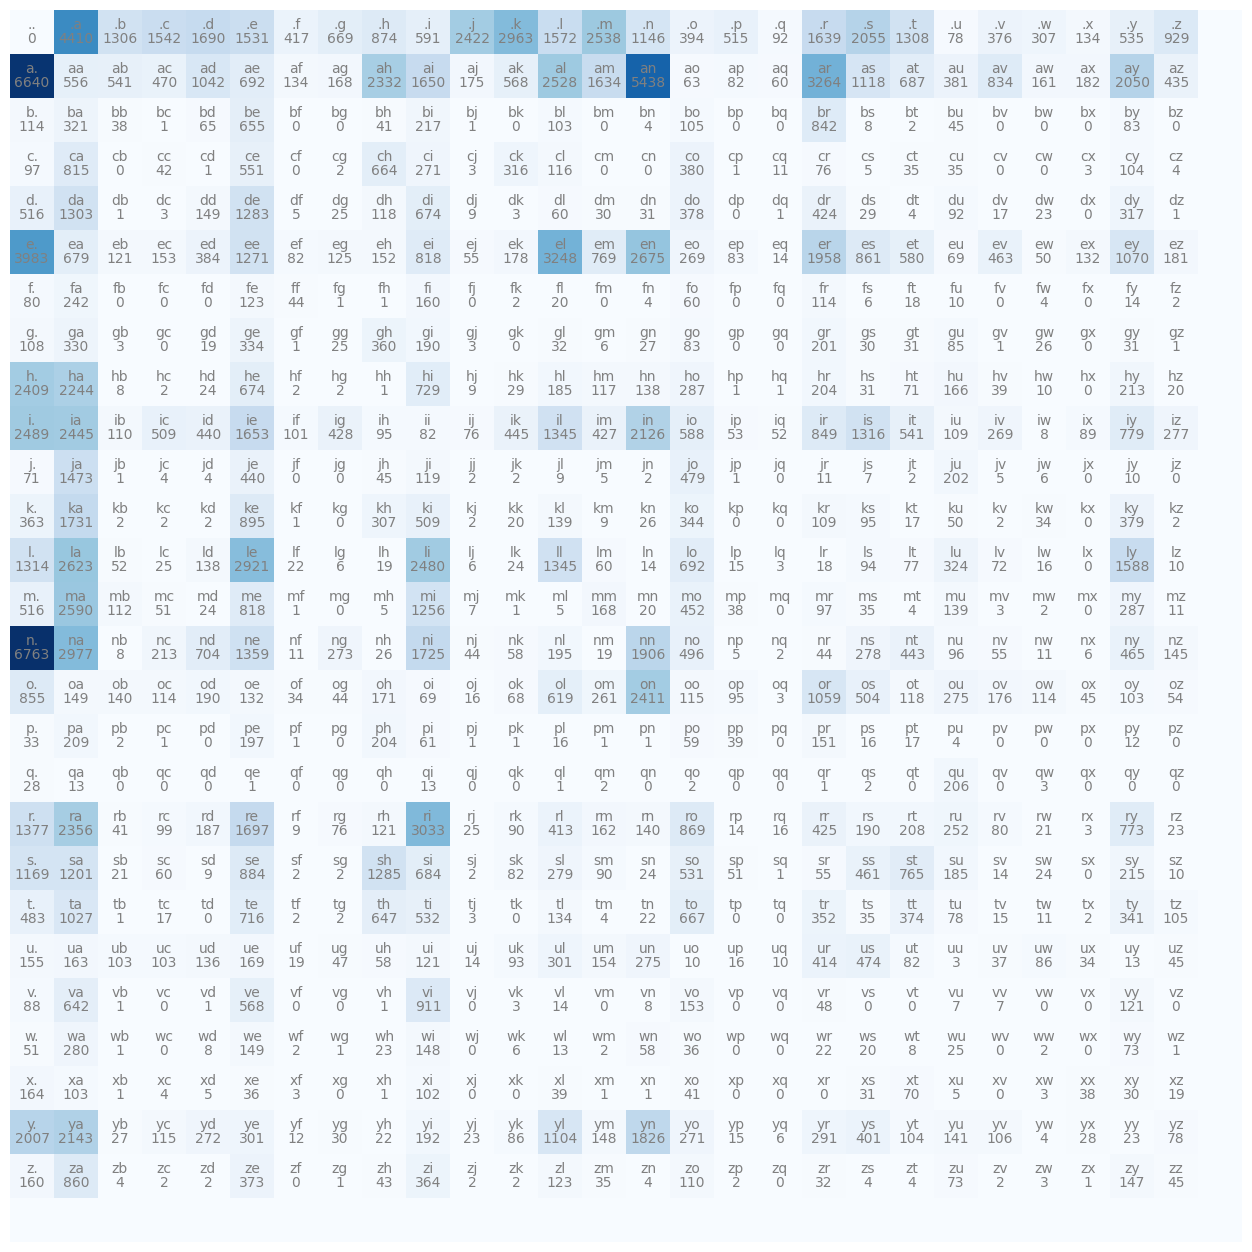

In [276]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')

In [277]:

for w in words[:3]:    
    
    chs = ['.'] + list(w) + ['.']     
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 

In [278]:
N[0]


tensor([   0, 4411, 1306, 1542, 1690, 1532,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  395,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929,    0], dtype=torch.int32)

In [279]:
P = (N+1).float()

P /= P.sum(axis = -1, keepdim=True)

g = torch.Generator().manual_seed(2147483647)

In [280]:
import torch

g = torch.Generator().manual_seed(2147483647)

torch.multinomial(P, num_samples=10, )

g = torch.Generator().manual_seed(2147483647)

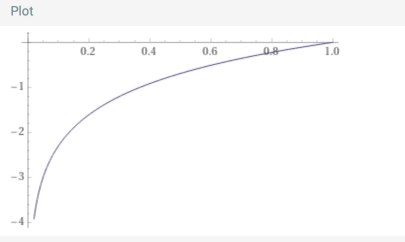

In [281]:
loglikelyhood= 0
count = 0
for w in words[:3]:    
    chs = ['.'] + list(w) + ['.']     
     
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 
        prob = P[ix1][ix2]
        logprob = torch.log(prob) 
        count +=1
        loglikelyhood+= logprob 
        # print(f"{ch1}{ch2} prob: {prob:.4f}")
        

m = count 
loss = -(loglikelyhood)/m
loss.item()

2.4244532585144043

In [282]:
for i in range(10):
    
    ix = 0 
    out = []
    
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() 
        out.append(itos[ix])
        if ix == 0:
            break
        
    print(''.join(out)) 

cava.
ayamaijowy.
aianeta.
rl.
miryndardyrioma.
kiinninaswila.
en.
ahlanyanlen.
tav.
sissth.


In [283]:
for i in range(10):
    
    ix = 0 
    out = []

    while True: 
        p  = P[ix] 
        ix =  torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix]) 
        if ix == 0 :
            break 
    print(''.join(out))
    
        


eygerinan.
sullyukrbrilahubrnidrianelkheyneligalah.
ka.
f.
elah.
m.
ri.
nil.
n.
diyn.


In [284]:
log_likelihood = 0.0
n = 0

for w in ["rith"]:     
    chs = ['.'] + list(w) + ['.']     
    for ch1,ch2 in zip(chs, chs[1:]):
        
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        Prob = P[ix1, ix2]
        N[ix1, ix2] += 1 
        logprob = torch.log(Prob)
        log_likelihood += logprob  
        
        n += 1 
        # print(f'{ch1}{ch2} : {Prob:.4f}')
        
print(f"{log_likelihood}")
print(f"{-log_likelihood}")
print(f"error {-log_likelihood/n}")

-11.205331802368164
11.205331802368164
error 2.2410664558410645


In [285]:
xs, ys = [], []

for w in words[:1]:     
    chs = ['.'] + list(w) + ['.']     
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 
        
        xs.append(ix1) 
        ys.append(ix2)

xs = torch.tensor(xs) 
ys = torch.tensor(ys) 
        
        
        
        

In [286]:
print(xs)

print(ys)


tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [287]:

for w in words[:3]:     
    chs = ['.'] + list(w) + ['.']     
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 
        
           

In [288]:
plt.figure(figsize=(16, 16))
t = P[0].sum(-1, keepdim=True)

<Figure size 1600x1600 with 0 Axes>

In [289]:
xs
t

tensor([1.])

In [290]:
ys

tensor([ 5, 13, 13,  1,  0])

In [291]:
import torch.nn.functional as F 

xenc = F.one_hot(xs, num_classes=27).float() # float is casting since one hot doesn't have the d.type 

xenc.shape

torch.Size([5, 27])

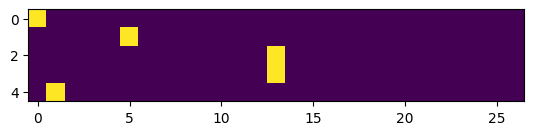

In [292]:
plt.imshow(xenc)

In [293]:
xenc.dtype # need float cuz it can fit into neural nets 




torch.float32

In [294]:

logits = xenc @ W 
logits

tensor([[ 1.5674e+00, -2.3729e-01, -2.7385e-02, -1.1008e+00,  2.8588e-01,
         -2.9644e-02, -1.5471e+00,  6.0489e-01,  7.9136e-02,  9.0462e-01,
         -4.7125e-01,  7.8682e-01, -3.2844e-01, -4.3297e-01,  1.3729e+00,
          2.9334e+00,  1.5618e+00, -1.6261e+00,  6.7716e-01, -8.4040e-01,
          9.8488e-01, -1.4837e-01, -1.4795e+00,  4.4830e-01, -7.0731e-02,
          2.4968e+00,  2.4448e+00],
        [ 4.7236e-01,  1.4830e+00,  3.1748e-01,  1.0588e+00,  2.3982e+00,
          4.6827e-01, -6.5650e-01,  6.1662e-01, -6.2198e-01,  5.1007e-01,
          1.3563e+00,  2.3445e-01, -4.5585e-01, -1.3132e-03, -5.1161e-01,
          5.5570e-01,  4.7458e-01, -1.3867e+00,  1.6229e+00,  1.7197e-01,
          9.8846e-01,  5.0657e-01,  1.0198e+00, -1.9062e+00, -4.2753e-01,
         -2.1259e+00,  9.6041e-01],
        [ 1.9359e-01,  1.0532e+00,  6.3393e-01,  2.5786e-01,  9.6408e-01,
         -2.4855e-01,  2.4756e-02, -3.0404e-02,  1.5622e+00, -4.4852e-01,
         -1.2345e+00,  1.1220e+00, -6.73

In [295]:
loglikelyhood = 0 
count = 0
N = (N+1).float()
P = N/N.sum(axis = 1 ,keepdim=True)

for w in words[:3]:     
    chs = ['.'] + list(w) + ['.']     
    for ch1,ch2 in zip(chs, chs[1:]):

        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 
        prob = P[ix1][ix2]
        count +=1 
        log_prob = torch.log(prob)
        loglikelyhood += log_prob 

loglikelyhood = loglikelyhood * -1
loss = loglikelyhood/count  
print(loss.item())

print(loss.dtype)
        

2.4216268062591553
torch.float32


In [296]:
#   ix =  torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
loglikelyhood = 0 
count = 0

P = N/N.sum(axis = 1 ,keepdim=True)

for w in words:     
    chs = ['.'] + list(w) + ['.']     
    for ch1,ch2 in zip(chs, chs[1:]):

        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 
        prob = P[ix1][ix2]
        count +=1 
        log_prob = torch.log(prob)
        loglikelyhood += log_prob 

loglikelyhood = loglikelyhood * -1
loss = log_likelihood/count  
print(loss.item())
        

-4.9114740249933675e-05


In [297]:
name = []
for _ in range(10):
    ix = 0 
    while True:
        p = P[ix]
        ix =  torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        name.append(itos[ix])
        if ix == 0:
            break
    print(''.join(name))
    name.clear()

noldale.
aireri.
ryndareiiyash.
ahe.
l.
lioverene.
miri.
akharo.
lein.
han.


In [298]:
xs, ys = [], []

for w in words:     
    chs = ['.'] + list(w) + ['.']     
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 
        xs.append(ix1) 
        ys.append(ix2)
xs = torch.tensor(xs)          # <-- add this
ys = torch.tensor(ys)          # <-- and this
    
xenc = F.one_hot(xs, num_classes=27).float() # float is casting since one hot doesn't have the d.type 


In [299]:
xenc.shape
print(xs.shape)
W = torch.randn([27,27], requires_grad=True)

torch.Size([228146])


In [300]:

(xenc @ W)[3][13] # how much 13 have fire power on 3
 

tensor(-0.4138, grad_fn=<SelectBackward0>)

In [301]:
logits = xenc @ W 
counts = logits.exp()
probs = counts/counts.sum(1, keepdim=True)
probs 

tensor([[0.0362, 0.1608, 0.0185,  ..., 0.0907, 0.0192, 0.0149],
        [0.0489, 0.0075, 0.0619,  ..., 0.0658, 0.0394, 0.0753],
        [0.0221, 0.0102, 0.0317,  ..., 0.0061, 0.1696, 0.0170],
        ...,
        [0.0164, 0.0052, 0.0077,  ..., 0.1150, 0.0310, 0.0278],
        [0.0115, 0.0547, 0.0060,  ..., 0.0295, 0.1009, 0.0256],
        [0.0475, 0.0273, 0.0255,  ..., 0.0964, 0.0258, 0.0752]],
       grad_fn=<DivBackward0>)

In [302]:
del xs 
del ys 

xs, ys = [], []

for w in words: # the first word  
    chs = ['.'] + list(w) + ['.']     
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1 
        xs.append(ix1) 
        ys.append(ix2)
        
xs = torch.tensor(xs)          
ys = torch.tensor(ys)         
    
xenc = F.one_hot(xs, num_classes=27).float() 

In [303]:
xs.shape

torch.Size([228146])

In [304]:
xenc = F.one_hot(xs, num_classes=27).float() # float is casting since one hot doesn't have the d.type 
logits = xenc @ W # log of count 
counts = torch.exp(logits) # counts 
probs = counts/counts.sum(axis = 1 , keepdim=True)



In [305]:

xs

tensor([ 0,  5, 13,  ..., 25, 26, 24])

In [306]:
ys

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [307]:
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item()  # input character index
    y = ys[i].item()  # label character index
    print('--------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i])
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())


--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0362, 0.1608, 0.0185, 0.0249, 0.0593, 0.0285, 0.0016, 0.0917, 0.0633,
        0.0093, 0.0139, 0.0292, 0.0058, 0.0127, 0.0037, 0.0187, 0.0285, 0.0549,
        0.0148, 0.0267, 0.0023, 0.0632, 0.0606, 0.0463, 0.0907, 0.0192, 0.0149],
       grad_fn=<SelectBackward0>)
label (actual next character): 5
probability assigned by the net to the the correct character: 0.028457630425691605
log likelihood: -3.5593390464782715
negative log likelihood: 3.5593390464782715
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0489, 0.0075, 0.0619, 0.0021, 0.0105, 0.0134, 0.0062, 0.1042, 0.0133,
        0.0291, 0.0571, 0.0306, 0.1727, 0.0505, 0.0447, 0.0101, 0.0161, 0.0397,
        0.0350, 0.0121, 0.0099, 0.0141, 0.0212, 0.0085, 0.0658, 0.0394, 0.0753],
       grad_fn=<SelectBackward0>)
label (actual next characte

In [309]:
# wrting the 
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27),generator=g,requires_grad=True)

num = xs.nelement()
for _ in range(1000):
    #Forward prop  
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W 
    counts = logits.exp()
    probs = counts/counts.sum(axis=1, keepdim=True)
    
    loss = -probs[torch.arange(num), ys].log().mean() 
    # loss = -probs[torch.arange(num), ys].log().mean() + (0.1 * ((W**2).mean))
    print(f"The lost is {loss}") 
    #backward prop 
    W.grad = None
    loss.backward()
    
    W.data = W.data + (-(80 * W.grad))
    
    

The lost is 3.758953809738159
The lost is 3.207859516143799
The lost is 2.986151933670044
The lost is 2.862355947494507
The lost is 2.7857298851013184
The lost is 2.73333477973938
The lost is 2.6941232681274414
The lost is 2.664029359817505
The lost is 2.6395750045776367
The lost is 2.620330810546875
The lost is 2.603856086730957
The lost is 2.591085910797119
The lost is 2.5792553424835205
The lost is 2.5705442428588867
The lost is 2.561448097229004
The lost is 2.5553581714630127
The lost is 2.5479300022125244
The lost is 2.543596029281616
The lost is 2.537245273590088
The lost is 2.5341243743896484
The lost is 2.5285847187042236
The lost is 2.5263562202453613
The lost is 2.521451234817505
The lost is 2.519892454147339
The lost is 2.515500545501709
The lost is 2.5144529342651367
The lost is 2.5104966163635254
The lost is 2.509866237640381
The lost is 2.506255865097046
The lost is 2.5059545040130615
The lost is 2.5026090145111084
The lost is 2.5025715827941895
The lost is 2.499458312988

In [315]:
name = []
for _ in range(10):
    ix = 0 
    while True:
        p = probs[ix]
        ix =  torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        name.append(itos[ix])
        if ix == 0:
            break
    print(''.join(name))
    name.clear()

aeeqymiyejlbananea.
ejnrtryf.
kied.
jatekna.
kmr.
mr.
rh.
alrlknaneduesrhkyatlanrtr.
nlsxdniisulaniecoztoiiezhrezh.
kr.
